# English Models Evaluation and Interpretability Metrics

This notebook exposes the results of the classification models trained and evaluated on English datasets (IMDB for Sentiment Analysis and WELFake/NEWS for Fake News Detection).
We compare four models:

**Sentiment Analysis (IMDB):**
- **BERT_SA_IMDB**
- **DistilBERT_SA_IMDB**

**Fake News Detection:**
- **BERT_WELFake**
- **DistilBERT_NEWS**

## 1. Metrics Comparison
The test metrics (Accuracy, Precision, Recall, F1 Score) for all models are presented below, grouped by their respective tasks.

In [1]:
import pandas as pd
import os

paths = {
    'BERT_SA_IMDB': '1_BERT_SA_IMDB/test_metrics.csv',
    'DistilBERT_SA_IMDB': '2_DistilBERT_SA_IMDB/test_metrics.csv',
    'BERT_WELFake': '3_BERT_WELFake/output_WELFake/test_metrics.csv',
    'DistilBERT_NEWS': '4_DistilBERT_NEWS/output_WELFake/test_metrics.csv'
}

dfs = []
for model_name, path in paths.items():
    df = pd.read_csv(path)
    df['Model'] = model_name
    if 'IMDB' in model_name:
        df['Task'] = 'Sentiment Analysis'
    else:
        df['Task'] = 'Fake News Detection'
    dfs.append(df)

df_combined = pd.concat(dfs).set_index(['Task', 'Model'])
df_combined

Accuracy  Precision    Recall  \
Task                Model                                               
Sentiment Analysis  BERT_SA_IMDB        0.941867   0.932411  0.952800   
                    DistilBERT_SA_IMDB  0.931867   0.918367  0.948000   
Fake News Detection BERT_WELFake        0.993867   0.994037  0.994037   
                    DistilBERT_NEWS     0.993600   0.995319  0.992222   

                                        F1_Score  
Task                Model                         
Sentiment Analysis  BERT_SA_IMDB        0.942495  
                    DistilBERT_SA_IMDB  0.932948  
Fake News Detection BERT_WELFake        0.994037  
                    DistilBERT_NEWS     0.993768

## 2. First Sample Analysis - Interpretability
Here we expose the first sample from the test sets, analyzing predictions using **LIME** and **SHAP** explainers for each model.

### 2.1 Sentiment Analysis (IMDB)

#### BERT_SA_IMDB
**LIME Explanation:**
![BERT_SA_IMDB LIME](1_BERT_SA_IMDB/Results/lime_explanation_0.png)

**SHAP Explanation:**
![BERT_SA_IMDB SHAP](1_BERT_SA_IMDB/Results/shap_explanation_0.png)

---
#### DistilBERT_SA_IMDB
**LIME Explanation:**
![DistilBERT_SA_IMDB LIME](2_DistilBERT_SA_IMDB/Results/lime_explanation_0.png)

**SHAP Explanation:**
![DistilBERT_SA_IMDB SHAP](2_DistilBERT_SA_IMDB/Results/shap_explanation_0.png)

### 2.2 Fake News Detection

#### BERT_WELFake
**LIME Explanation:**
![BERT_WELFake LIME](3_BERT_WELFake/output_WELFake/lime_explanation_0.png)

**SHAP Explanation:**
![BERT_WELFake SHAP](3_BERT_WELFake/output_WELFake/shap_explanation_0.png)

---
#### DistilBERT_NEWS
**LIME Explanation:**
![DistilBERT_NEWS LIME](4_DistilBERT_NEWS/output_WELFake/lime_explanation_0.png)

**SHAP Explanation:**
![DistilBERT_NEWS SHAP](4_DistilBERT_NEWS/output_WELFake/shap_explanation_0.png)

### Description and Interpretation

**Metrics Interpretation:**
- **Sentiment Analysis (IMDB):** Both BERT and DistilBERT models achieve high performance, with BERT slightly outperforming DistilBERT (~94.1% vs ~93.1% accuracy). The minor performance drop is expected when using a lighter, distilled model, trading a bit of accuracy for faster inference.
- **Fake News Detection:** Both models achieve near-perfect performance on this dataset (~99.3% accuracy and F1 score). This highlights that the models easily recognize the strong patterns separating real vs fake news in this specific dataset.

**Sample Interpretability (LIME & SHAP):**
- **LIME** images show the local importance of words, highlighting exactly which terms in the specific text sample drive the model towards a Positive/Negative or Real/Fake classification.
- **SHAP** plots demonstrate the cumulative shift from the base expectation. This is valuable to see how strongly certain features (words) push the prediction.
- By comparing BERT and DistilBERT explanations, we can often see that DistilBERT focuses on a similar but slightly compressed set of keywords compared to its larger counterpart. For Fake News, we can verify if the models are capturing semantic meaning or just dataset-specific artifacts (like specific names or uppercase words).

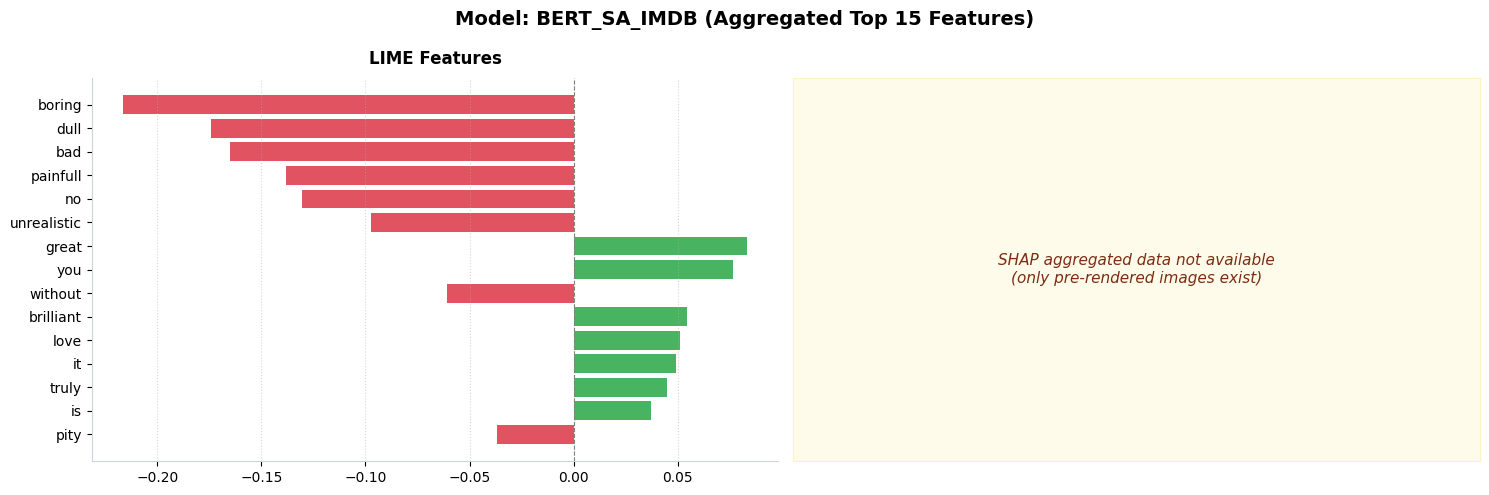

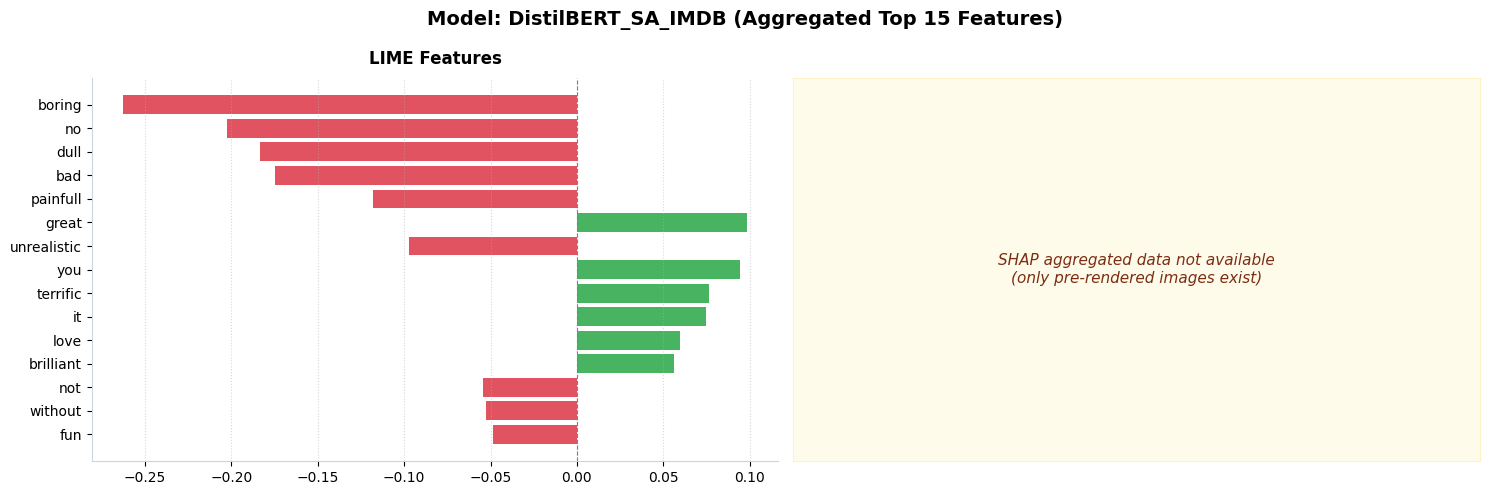

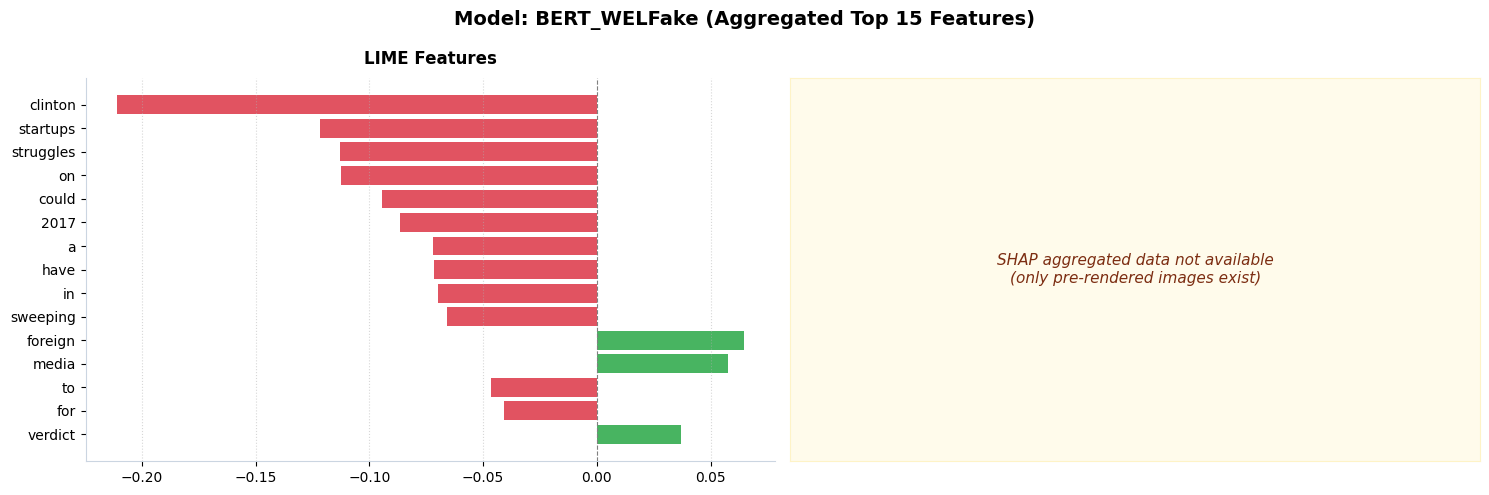

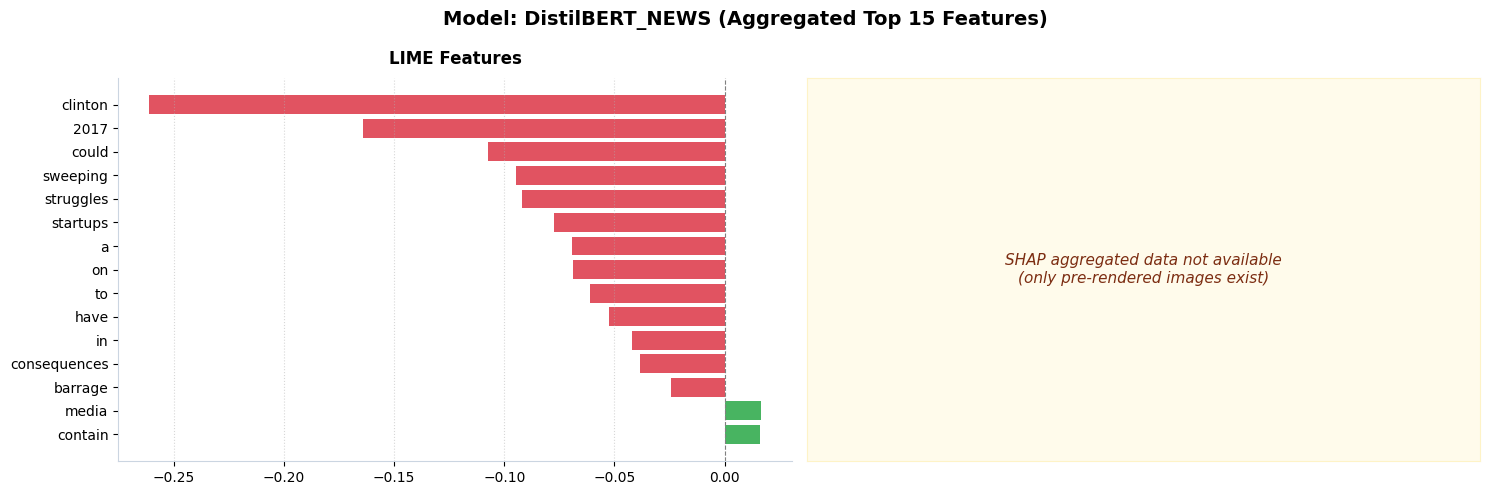

In [4]:
import os
import re
import json
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

def aggregate_model_explanations(model_dir):
    lime_w = defaultdict(float)
    shap_w = defaultdict(float)
    
    model_path = Path(model_dir)
    if not model_path.exists():
        return [], []
        
    for root, dirs, files in os.walk(model_path):
        for f in files:
            path = Path(root) / f
            if f == 'lime_summary.json':
                try:
                    with open(path, 'r', encoding='utf-8') as file:
                        data = json.load(file)
                    for entry in data:
                        for w, wt in entry.get('top_words', []):
                            cw = w.strip().strip(',.-!?;:\\"\'()[]{}').lower()
                            if cw: lime_w[cw] += wt
                except Exception:
                    pass
            elif f.startswith('lime_explanation_') and f.endswith('.html'):
                try:
                    with open(path, 'r', encoding='utf-8') as file:
                        content = file.read()
                    m = re.search(r'exp\.show\(\s*(\[.*?\])\s*,\s*\d+,\s*exp_div\);', content)
                    if m:
                        data = json.loads(m.group(1))
                        for w, wt in data:
                            cw = w.strip().strip(',.-!?;:\\"\'()[]{}').lower()
                            if cw: lime_w[cw] += wt
                except Exception:
                    pass
            elif f == 'shap_summary.json':
                try:
                    with open(path, 'r', encoding='utf-8') as file:
                        data = json.load(file)
                    for entry in data:
                        for t, wt in entry.get('top_tokens', []):
                            ct = t.strip().strip(',.-!?;:\\"\'()[]{}').lower()
                            if ct: shap_w[ct] += wt
                except Exception:
                    pass
                        
    top_lime = sorted(lime_w.items(), key=lambda x: abs(x[1]), reverse=True)[:15]
    top_shap = sorted(shap_w.items(), key=lambda x: abs(x[1]), reverse=True)[:15]
    return top_lime, top_shap

english_models = {
    'BERT_SA_IMDB': '1_BERT_SA_IMDB',
    'DistilBERT_SA_IMDB': '2_DistilBERT_SA_IMDB',
    'BERT_WELFake': '3_BERT_WELFake',
    'DistilBERT_NEWS': '4_DistilBERT_NEWS'
}

for model_name, model_dir in english_models.items():
    top_lime, top_shap = aggregate_model_explanations(model_dir)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Model: {model_name} (Aggregated Top 15 Features)", fontsize=14, fontweight='bold')
    
    if top_lime:
        lime_words, lime_weights = zip(*top_lime[::-1])
        colors = ['#28a745' if w > 0 else '#dc3545' for w in lime_weights]
        ax1.barh(lime_words, lime_weights, color=colors, alpha=0.85)
        ax1.set_title("LIME Features", fontsize=12, fontweight='bold', pad=10)
        ax1.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.spines['left'].set_color('#cbd5e1')
        ax1.spines['bottom'].set_color('#cbd5e1')
        ax1.grid(axis='x', linestyle=':', alpha=0.5)
    else:
        ax1.text(0.5, 0.5, "No LIME data found", ha='center', va='center', fontsize=12, color='gray')
        ax1.axis('off')
        
    if top_shap:
        shap_tokens, shap_weights = zip(*top_shap[::-1])
        colors = ['#007bff' if w > 0 else '#ffc107' for w in shap_weights]
        ax2.barh(shap_tokens, shap_weights, color=colors, alpha=0.85)
        ax2.set_title("SHAP Features", fontsize=12, fontweight='bold', pad=10)
        ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.spines['left'].set_color('#cbd5e1')
        ax2.spines['bottom'].set_color('#cbd5e1')
        ax2.grid(axis='x', linestyle=':', alpha=0.5)
    else:
        ax2.text(0.5, 0.5, "SHAP aggregated data not available\n(only pre-rendered images exist)", 
                 ha='center', va='center', fontsize=11, color='#7c2d12', style='italic')
        ax2.set_facecolor('#fffbeb')
        ax2.spines['top'].set_color('#fef3c7')
        ax2.spines['right'].set_color('#fef3c7')
        ax2.spines['left'].set_color('#fef3c7')
        ax2.spines['bottom'].set_color('#fef3c7')
        ax2.set_xticks([])
        ax2.set_yticks([])
        
    plt.tight_layout()
    plt.show()
